<a href="https://colab.research.google.com/github/ValentinBarco/Aprendizaje-de-maquina/blob/master/Proyecto_Final_Good_Bad_En_Cascada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [120]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Prueba si el programa lee correctamente la imagen


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:10: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  # Remove the CWD from sys.path while we load stuff.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:14: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  


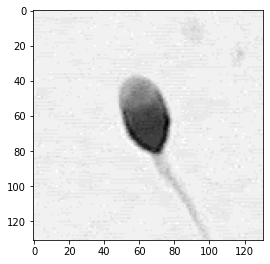

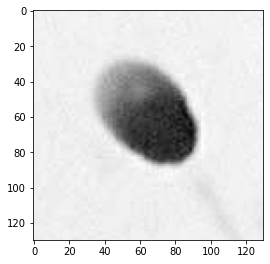

In [121]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img_normal     = cv2.imread('/content/drive/MyDrive/Colab Notebooks/HuSHem/01_Normal/image_001.BMP',0)
img_good = cv2.imread('/content/drive/MyDrive/Colab Notebooks/High Quality Sperm - Labeled/Good Sperm/2017a_99_99_2450_3741.png',0)
plt.figure(figsize=(14,14))
plt.subplot(1,3,2)
plt.imshow(img_normal,cmap='gray')
plt.subplot(1,3,2)
plt.figure(figsize=(14,14))
plt.subplot(1,3,2)
plt.imshow(img_good,cmap='gray')
plt.subplot(1,3,2)

##Cargo los Datasets con las imagenes

In [122]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage.transform import resize
from skimage import exposure
from skimage.io import imshow
Normal = '/content/drive/MyDrive/Colab Notebooks/HuSHem/01_Normal' 
GoodSperm_Training = []
Normal_Training = []

for img in os.listdir(Normal):
  img = cv2.imread(os.path.join(Normal,img))
  img = cv2.resize(img,(256,128),interpolation=cv2.INTER_AREA)
  fd = hog(img, orientations=9, pixels_per_cell=(16, 16),cells_per_block=(2, 2), multichannel=True) 
  fd = fd/fd.max()
  #fd = exposure.rescale_intensity(fd, in_range= (0,5));
  GoodSperm_Training.append(fd)
  Normal_Training.append(fd)


In [123]:
Tapered = '/content/drive/MyDrive/Colab Notebooks/HuSHem/02_Tapered' 
BadSperm_Training = []
Tapered_Training = []

for img in os.listdir(Tapered):
  img = cv2.imread(os.path.join(Tapered,img))
  img = cv2.resize(img,(256,128),interpolation=cv2.INTER_AREA)
  fd = hog(img, orientations=9, pixels_per_cell=(16, 16),cells_per_block=(2, 2), multichannel=True) 
  fd = fd/fd.max()
  #fd = exposure.rescale_intensity(fd, in_range= (0,5));
  BadSperm_Training.append(fd)
  Tapered_Training.append(fd)

In [124]:
Pyriform = '/content/drive/MyDrive/Colab Notebooks/HuSHem/03_Pyriform' 
Pyriform_Training = []


for img in os.listdir(Pyriform):
  img = cv2.imread(os.path.join(Pyriform,img))
  img = cv2.resize(img,(256,128),interpolation=cv2.INTER_AREA)
  fd = hog(img, orientations=9, pixels_per_cell=(16, 16),cells_per_block=(2, 2), multichannel=True) 
  fd = fd/fd.max()
  #fd = exposure.rescale_intensity(fd, in_range= (0,5));
  BadSperm_Training.append(fd)
  Pyriform_Training.append(fd)

In [125]:
Amorphous = '/content/drive/MyDrive/Colab Notebooks/HuSHem/04_Amorphous' 
Amorphous_Training = []


for img in os.listdir(Amorphous):
  img = cv2.imread(os.path.join(Amorphous,img))
  img = cv2.resize(img,(256,128),interpolation=cv2.INTER_AREA)
  fd = hog(img, orientations=9, pixels_per_cell=(16, 16),cells_per_block=(2, 2), multichannel=True) 
  fd = fd/fd.max()
  fd = exposure.rescale_intensity(fd, in_range= (0,5));
  BadSperm_Training.append(fd)
  Amorphous_Training.append(fd)

##Asigno los targets 



1.   Esperma de buena calidad
2.   Esperma de mala calidad









In [126]:
import pandas as pd

Data_GoodSperm = pd.DataFrame(GoodSperm_Training)
target_GoodSperm = pd.DataFrame([1]*len(Data_GoodSperm))
Data_BadSperm = pd.DataFrame(BadSperm_Training)
target_BadSperm = pd.DataFrame([2]*len(Data_BadSperm))


Dataset = pd.concat([Data_GoodSperm ,Data_BadSperm],ignore_index= True,axis=0)
target = pd.concat([target_GoodSperm, target_BadSperm],ignore_index= True,axis=0)

target.head

<bound method NDFrame.head of      0
0    1
1    1
2    1
3    1
4    1
..  ..
211  2
212  2
213  2
214  2
215  2

[216 rows x 1 columns]>

#Modelo: K Vecinos mas cercanos

###Calculo de n_vecinos para mayor presicion

In [127]:
Data_GoodSperm.head

<bound method NDFrame.head of         0         1         2     ...      3777      3778      3779
0   0.677305  0.043537  0.299410  ...  0.349675  0.168694  0.242038
1   0.305976  0.095141  0.101506  ...  0.111089  0.053021  0.215869
2   0.144140  0.035626  0.082354  ...  0.299574  0.107282  0.207858
3   0.548121  0.272201  0.510099  ...  0.440277  0.250454  0.229532
4   0.792181  0.210902  0.356442  ...  0.131710  0.041728  0.124336
5   0.571663  0.227638  0.398849  ...  0.278407  0.291209  0.191567
6   0.454899  0.200192  0.475727  ...  0.343023  0.348015  0.300272
7   0.535919  0.102794  0.434714  ...  0.286997  0.152226  0.114360
8   0.542508  0.077662  0.353127  ...  0.184789  0.083383  0.142722
9   0.445633  0.139982  0.377481  ...  0.049097  0.042637  0.183587
10  0.455848  0.197700  0.501666  ...  0.327119  0.176544  0.272204
11  0.580431  0.152198  0.364389  ...  0.297057  0.368162  0.239085
12  0.407043  0.102293  0.287088  ...  0.053156  0.038616  0.068969
13  0.656684  0.13

In [128]:
#Importacion de librerias

from sklearn import neighbors
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score

#Separacion entre datos de entrenamiento y datos de prueba 

X_train, X_test, y_train, y_test = train_test_split(Dataset, target, test_size=0.2, random_state=3)

In [129]:
for n in range(1,10):
  Kvecinos = neighbors.KNeighborsClassifier(n_neighbors=n)
  Kvecinos.fit(X_train, y_train)
  y_pred = Kvecinos.predict(X_test)
  Score = precision_score(y_test, y_pred, average='micro')
  print("La Presicion del Modelo con " + str(n) + " vecinos es:",Score)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


La Presicion del Modelo con 1 vecinos es: 0.8181818181818182
La Presicion del Modelo con 2 vecinos es: 0.8181818181818182
La Presicion del Modelo con 3 vecinos es: 0.8636363636363636


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


La Presicion del Modelo con 4 vecinos es: 0.8409090909090909
La Presicion del Modelo con 5 vecinos es: 0.8181818181818182
La Presicion del Modelo con 6 vecinos es: 0.8409090909090909


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  This is separate from the ipykernel package so we can avoid doing imports until


La Presicion del Modelo con 7 vecinos es: 0.8181818181818182
La Presicion del Modelo con 8 vecinos es: 0.8409090909090909
La Presicion del Modelo con 9 vecinos es: 0.8181818181818182


##Entrenamiento del Modelo con el N optimo

In [130]:
## Como podemos notar el modelo tiene mas presicion con n = 7

X_train, X_test, y_train, y_test = train_test_split(Dataset, target, test_size=0.2, random_state=3)

Kvecinos = neighbors.KNeighborsClassifier(n_neighbors=7)
Kvecinos.fit(X_train, y_train)

y_pred_Kvecinos = Kvecinos.predict(X_test)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  


#Matiz de Confusion

Precision: 0.8181818181818182
Exactitud: 0.8181818181818182
Sensibilidad: 0.7708333333333333
Puntaje: 0.8181818181818182


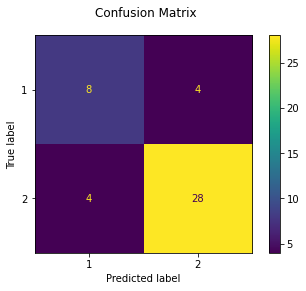

In [131]:
disp = metrics.plot_confusion_matrix(Kvecinos, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix");



from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

Precision = precision_score(y_test, y_pred_Kvecinos, average='micro')
Exactitud = accuracy_score(y_test,y_pred_Kvecinos)
Sensibilidad = recall_score(y_test,y_pred_Kvecinos,average='macro')
Puntaje = f1_score(y_test,y_pred_Kvecinos,average = 'micro')
print('Precision: '+ str(Precision))
print('Exactitud: '+ str(Exactitud))
print('Sensibilidad: '+ str(Sensibilidad))
print('Puntaje: '+ str(Puntaje))

#Modelo: Support Vector Machine

In [132]:

from sklearn.model_selection import train_test_split
from sklearn import svm, metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
 
X_train, X_test, y_train, y_test = train_test_split(Dataset, target, shuffle = True, test_size=0.15, random_state=1)

clasificador = svm.SVC(kernel = 'linear')
clasificador.fit(X_train, y_train)

y_pred_Vector = clasificador.predict(X_test)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Precision: 0.9090909090909091


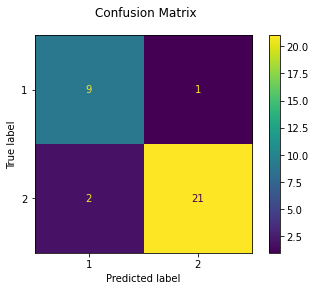

In [133]:
disp = metrics.plot_confusion_matrix(clasificador, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")


Precision = precision_score(y_test, y_pred_Vector, average='micro')


print('Precision: '+ str(Precision))


#Modelo: Arbol de Decision


In [134]:
from sklearn.tree import DecisionTreeClassifier


Arbol = DecisionTreeClassifier(criterion = 'entropy')
Arbol.fit(X_train, y_train)
y_pred_Arbol = Arbol.predict(X_test)

Precision: 0.7878787878787878


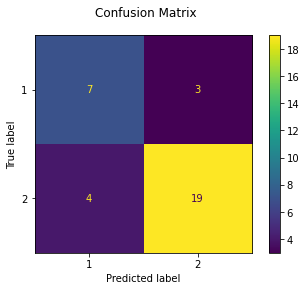

In [135]:
from sklearn.metrics import precision_score
disp = metrics.plot_confusion_matrix(Arbol, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred_Arbol, average='micro')
print('Precision: '+ str(Precision))

#Modelo: Bosque Aleatorio de Clasificacion

In [136]:

from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(Dataset, target, shuffle = True, test_size=0.15, random_state=1)

Bosque = RandomForestClassifier(n_estimators=10, criterion = 'entropy')
Bosque.fit(X_test,y_test);
y_pred_Bosque = Bosque.predict(X_test)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  import sys


Precision: 0.9696969696969697


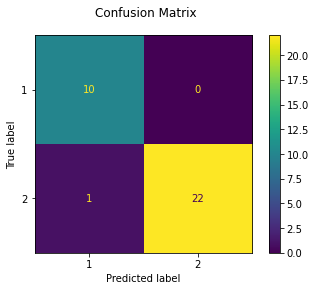

In [137]:
disp = metrics.plot_confusion_matrix(Bosque, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred_Bosque, average='micro')
print('Precision: '+ str(Precision))

#Modelo: Bayes

In [138]:
X_train, X_test, y_train, y_test = train_test_split(Dataset, target, shuffle = True, test_size=0.1, random_state=1)
from sklearn.naive_bayes import GaussianNB

Bayes = GaussianNB()
Bayes.fit(X_train, y_train)

y_pred_Bayes = Bayes.predict(X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/naive_bayes.py:206: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Precision: 0.5909090909090909


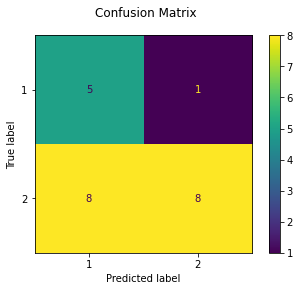

In [139]:
from sklearn.metrics import precision_score
disp = metrics.plot_confusion_matrix(Bayes, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred_Bayes, average='micro')
print('Precision: '+ str(Precision))

In [140]:
Data_Tapered = pd.DataFrame(Tapered_Training)
target_Tapered = pd.DataFrame([1]*len(Data_Tapered))
Data_Pyriform = pd.DataFrame(Pyriform_Training)
target_Pyriform =pd.DataFrame([2]*len(Data_Pyriform))
Data_Amorphous = pd.DataFrame(Amorphous_Training)
target_Amorphous =pd.DataFrame([3]*len(Data_Amorphous))

DatasetTipo = pd.concat([Data_Tapered, Data_Pyriform, Data_Amorphous],ignore_index= True,axis=0)
targetTipo = pd.concat([target_Tapered , target_Pyriform, target_Amorphous],ignore_index= True,axis=0)

target.head

<bound method NDFrame.head of      0
0    1
1    1
2    1
3    1
4    1
..  ..
211  2
212  2
213  2
214  2
215  2

[216 rows x 1 columns]>

#Modelo: K Vecinos mas cercanos

###Calculo de n_vecinos para mayor presicion

In [141]:
#Separacion entre datos de entrenamiento y datos de prueba 

X_train, X_test, y_train, y_test = train_test_split(DatasetTipo, targetTipo, test_size=0.2, random_state=3)

for n in range(1,10):
  Kvecinos = neighbors.KNeighborsClassifier(n_neighbors=n)
  Kvecinos.fit(X_train, y_train)
  y_pred = Kvecinos.predict(X_test)
  Score = precision_score(y_test, y_pred, average='micro')
  print("La Presicion del Modelo con " + str(n) + " vecinos es:",Score)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys


La Presicion del Modelo con 1 vecinos es: 0.7878787878787878
La Presicion del Modelo con 2 vecinos es: 0.7575757575757576
La Presicion del Modelo con 3 vecinos es: 0.7878787878787878
La Presicion del Modelo con 4 vecinos es: 0.7878787878787878


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys


La Presicion del Modelo con 5 vecinos es: 0.7878787878787878
La Presicion del Modelo con 6 vecinos es: 0.7878787878787878
La Presicion del Modelo con 7 vecinos es: 0.8787878787878788
La Presicion del Modelo con 8 vecinos es: 0.8181818181818182
La Presicion del Modelo con 9 vecinos es: 0.8484848484848485


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  import sys


##Entrenamiento del Modelo con el N optimo

In [142]:
## Como podemos notar el modelo tiene mas presicion con n = 7

X_train, X_test, y_train, y_test = train_test_split(DatasetTipo, targetTipo, test_size=0.2, random_state=3)

Kvecinos = neighbors.KNeighborsClassifier(n_neighbors=7)
Kvecinos.fit(X_train, y_train)

y_pred = Kvecinos.predict(X_test)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  


#Matiz de Confusion

Precision: 0.8787878787878788
Exactitud: 0.8787878787878788
Sensibilidad: 0.8703703703703703
Puntaje: 0.8787878787878788


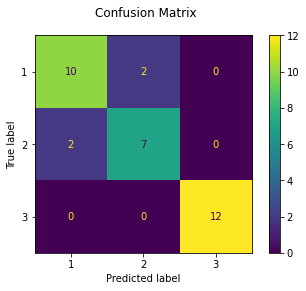

In [143]:
disp = metrics.plot_confusion_matrix(Kvecinos, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix");



from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

Precision = precision_score(y_test, y_pred, average='micro')
Exactitud = accuracy_score(y_test,y_pred)
Sensibilidad = recall_score(y_test,y_pred,average='macro')
Puntaje = f1_score(y_test,y_pred,average = 'micro')
print('Precision: '+ str(Precision))
print('Exactitud: '+ str(Exactitud))
print('Sensibilidad: '+ str(Sensibilidad))
print('Puntaje: '+ str(Puntaje))

#Modelo: Support Vector Machine

In [144]:

from sklearn.model_selection import train_test_split
from sklearn import svm, metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
 

Vector= svm.SVC(kernel = 'linear')
Vector.fit(X_train, y_train)

y_pred = Vector.predict(X_test)


/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Precision: 0.8787878787878788


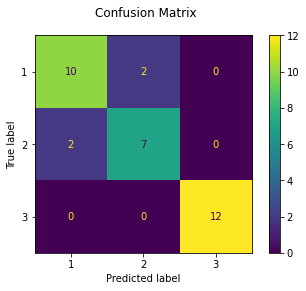

In [145]:
disp = metrics.plot_confusion_matrix(Vector, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")


Precision = precision_score(y_test, y_pred, average='micro')


print('Precision: '+ str(Precision))

#Modelo: Arbol de Decision

In [146]:
from sklearn.tree import DecisionTreeClassifier


Arbol = DecisionTreeClassifier(criterion = 'entropy')
Arbol.fit(X_train, y_train)
y_pred = Arbol.predict(X_test)

Precision: 0.696969696969697


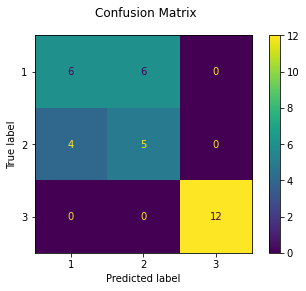

In [147]:
from sklearn.metrics import precision_score
disp = metrics.plot_confusion_matrix(Arbol, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred, average='micro')
print('Precision: '+ str(Precision))

#Modelo: Bosque Aleatorio de Clasificacion

In [148]:

from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(DatasetTipo, targetTipo, shuffle = True, test_size=0.15, random_state=1)

Bosque = RandomForestClassifier(n_estimators=10, criterion = 'entropy')
Bosque.fit(X_test,y_test);
y_pred = Bosque.predict(X_test)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  import sys


Precision: 0.96


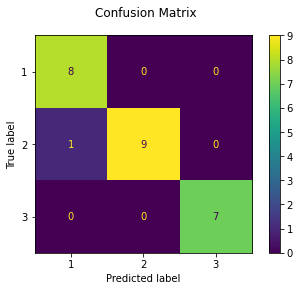

In [149]:
disp = metrics.plot_confusion_matrix(Bosque, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred, average='micro')
print('Precision: '+ str(Precision))

#Modelo: Bayes

In [150]:
from sklearn.naive_bayes import GaussianNB

Bayes = GaussianNB()
Bayes.fit(X_train, y_train)

y_pred = Bayes.predict(X_test)

/usr/local/lib/python3.7/dist-packages/sklearn/naive_bayes.py:206: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Precision: 0.72


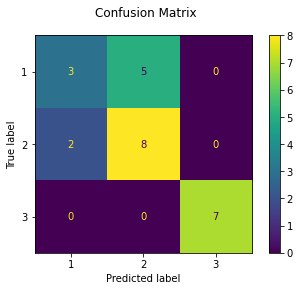

In [151]:
from sklearn.metrics import precision_score
disp = metrics.plot_confusion_matrix(Bayes, X_test, y_test)
disp.figure_.suptitle("Confusion Matrix")

Precision = precision_score(y_test, y_pred, average='micro')
print('Precision: '+ str(Precision))